In [221]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# escalado
from sklearn.preprocessing import StandardScaler
# métricas
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import pickle

import warnings
warnings.filterwarnings('ignore')

# Proyecto de K Nearest Neighbours

In [222]:
# Cargamos el Dataset y le echamos un primer vistazo
df = pd.read_csv('https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv', sep = ';')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [223]:
df.shape

(1599, 12)

In [224]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


No hay valores nulos, todas las variables son de tipo nuumérico

In [225]:
# vemos qué cantidad de datos hay en cada calidad
df["quality"].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

las vamos a reagrupar en calidad baja (0), media (1) y alta (2)

In [226]:
df.loc[df['quality'] <= 5, 'quality'] = 0   # baja
df.loc[df['quality'] == 6, 'quality'] = 1  # media
df.loc[df['quality'] >= 7, 'quality'] = 2    # alta
# vemos qué cantidad de datos hay en cada calidad
df["quality"].value_counts().sort_index()

quality
0    744
1    638
2    217
Name: count, dtype: int64

In [227]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,0.670419
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.701915
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,0.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,0.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,1.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,1.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,2.000000


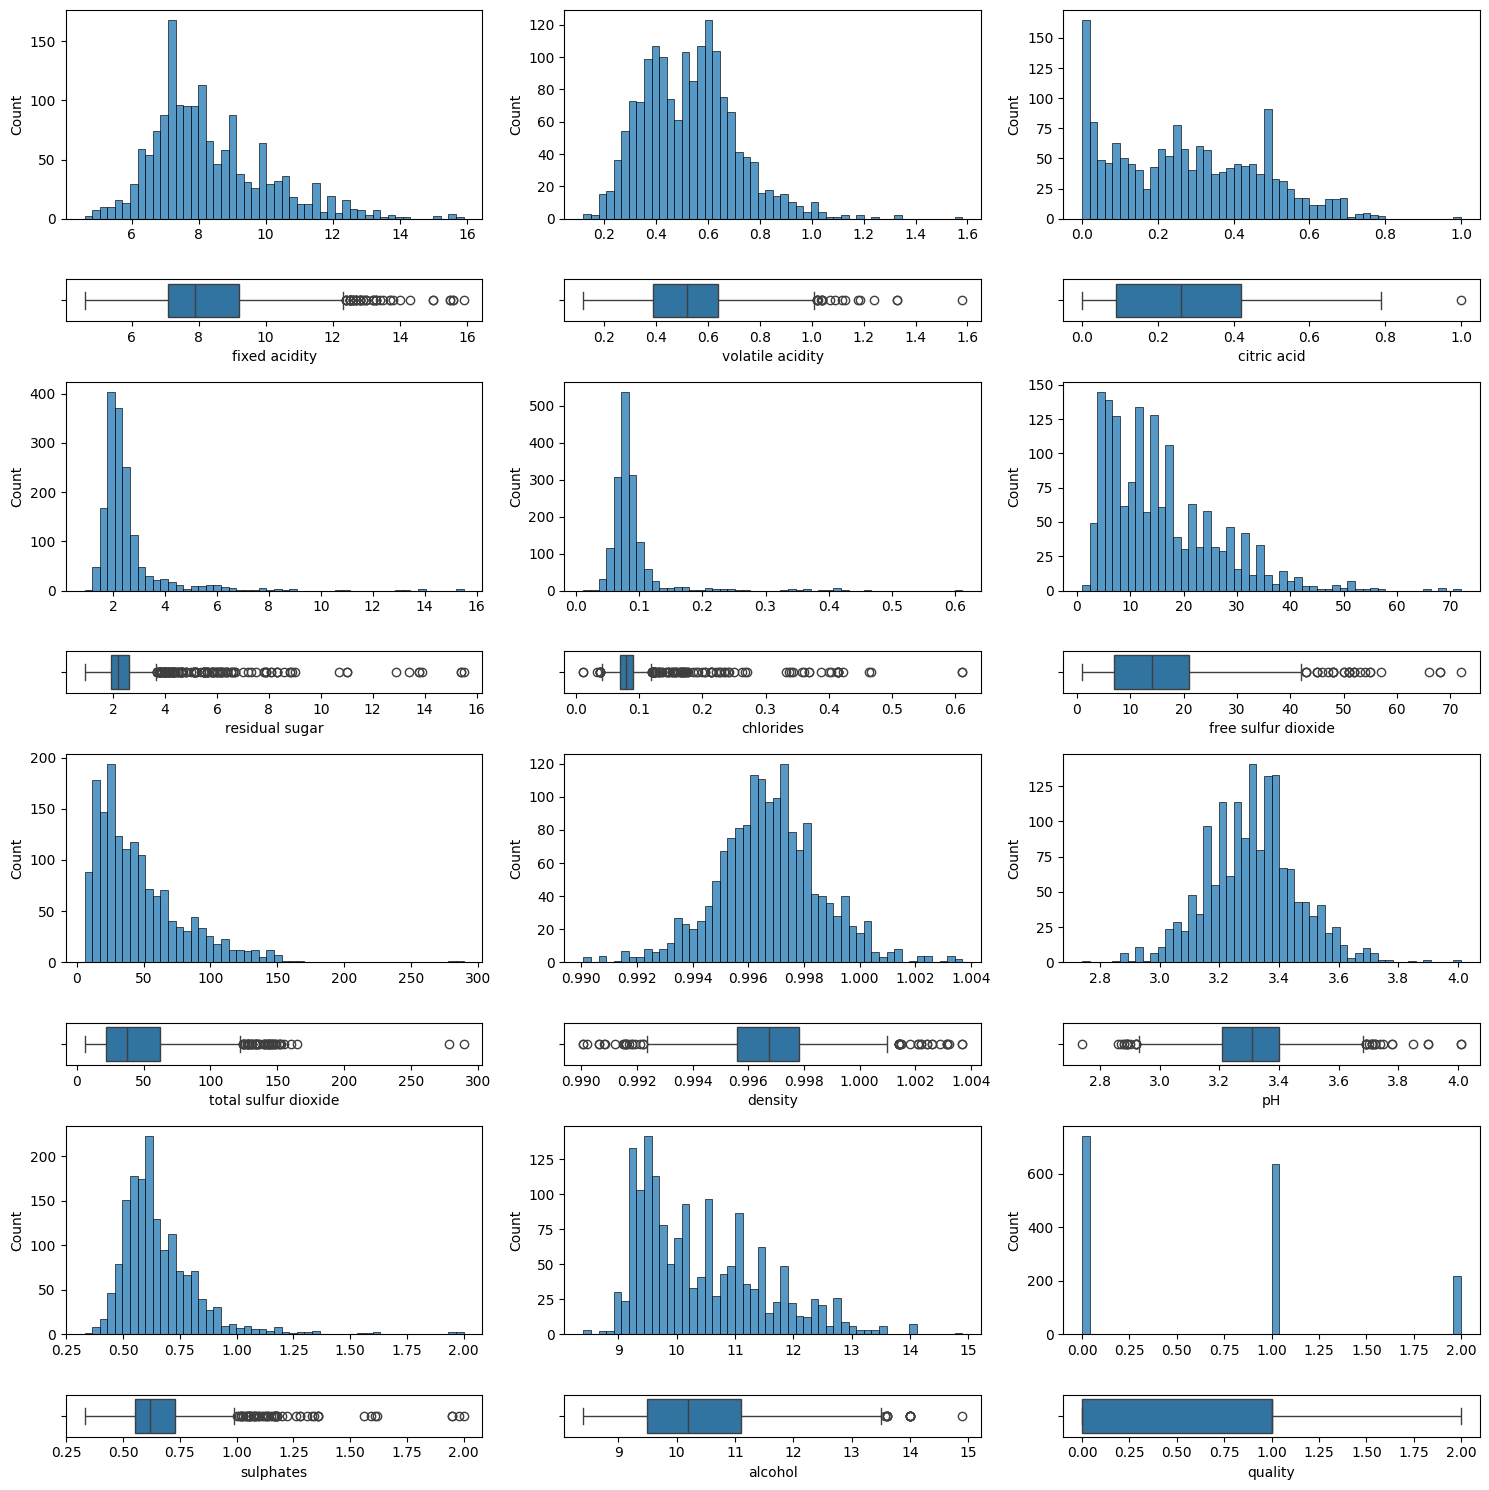

In [228]:
fig, axis = plt.subplots(8, 3, figsize = (15, 15), gridspec_kw={'height_ratios': [5, 1, 5, 1, 5, 1, 5, 1]})
# Crear una figura múltiple con histogramas y diagramas de caja
sns.histplot(ax = axis[0, 0], data = df, x = "fixed acidity", bins = 50).set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = df, x = "fixed acidity")

sns.histplot(ax = axis[0, 1], data = df, x = "volatile acidity", bins = 50).set(xlabel = None)
sns.boxplot(ax = axis[1, 1], data = df, x = "volatile acidity")

sns.histplot(ax = axis[0, 2], data = df, x = "citric acid", bins = 50).set(xlabel = None)
sns.boxplot(ax = axis[1, 2], data = df, x = "citric acid")

sns.histplot(ax = axis[2, 0], data = df, x = "residual sugar", bins = 50).set(xlabel = None)
sns.boxplot(ax = axis[3, 0], data = df, x = "residual sugar")

sns.histplot(ax = axis[2, 1], data = df, x = "chlorides", bins = 50).set(xlabel = None)
sns.boxplot(ax = axis[3, 1], data = df, x = "chlorides")

sns.histplot(ax = axis[2, 2], data = df, x = "free sulfur dioxide", bins = 50).set(xlabel = None)
sns.boxplot(ax = axis[3, 2], data = df, x = "free sulfur dioxide")

sns.histplot(ax = axis[4, 0], data = df, x = "total sulfur dioxide", bins = 50).set(xlabel = None)
sns.boxplot(ax = axis[5, 0], data = df, x = "total sulfur dioxide")

sns.histplot(ax = axis[4, 1], data = df, x = "density", bins = 50).set(xlabel = None)
sns.boxplot(ax = axis[5, 1], data = df, x = "density")

sns.histplot(ax = axis[4, 2], data = df, x = "pH", bins = 50).set(xlabel = None)
sns.boxplot(ax = axis[5, 2], data = df, x = "pH")

sns.histplot(ax = axis[6, 0], data = df, x = "sulphates", bins = 50).set(xlabel = None)
sns.boxplot(ax = axis[7, 0], data = df, x = "sulphates")

sns.histplot(ax = axis[6, 1], data = df, x = "alcohol", bins = 50).set(xlabel = None)
sns.boxplot(ax = axis[7, 1], data = df, x = "alcohol")

sns.histplot(ax = axis[6, 2], data = df, x = "quality", bins = 50).set(xlabel = None)
sns.boxplot(ax = axis[7, 2], data = df, x = "quality")

plt.tight_layout()

El Dataset parece bastante limpio y representativo, no parece tener outliers severos ni errores de medición. 

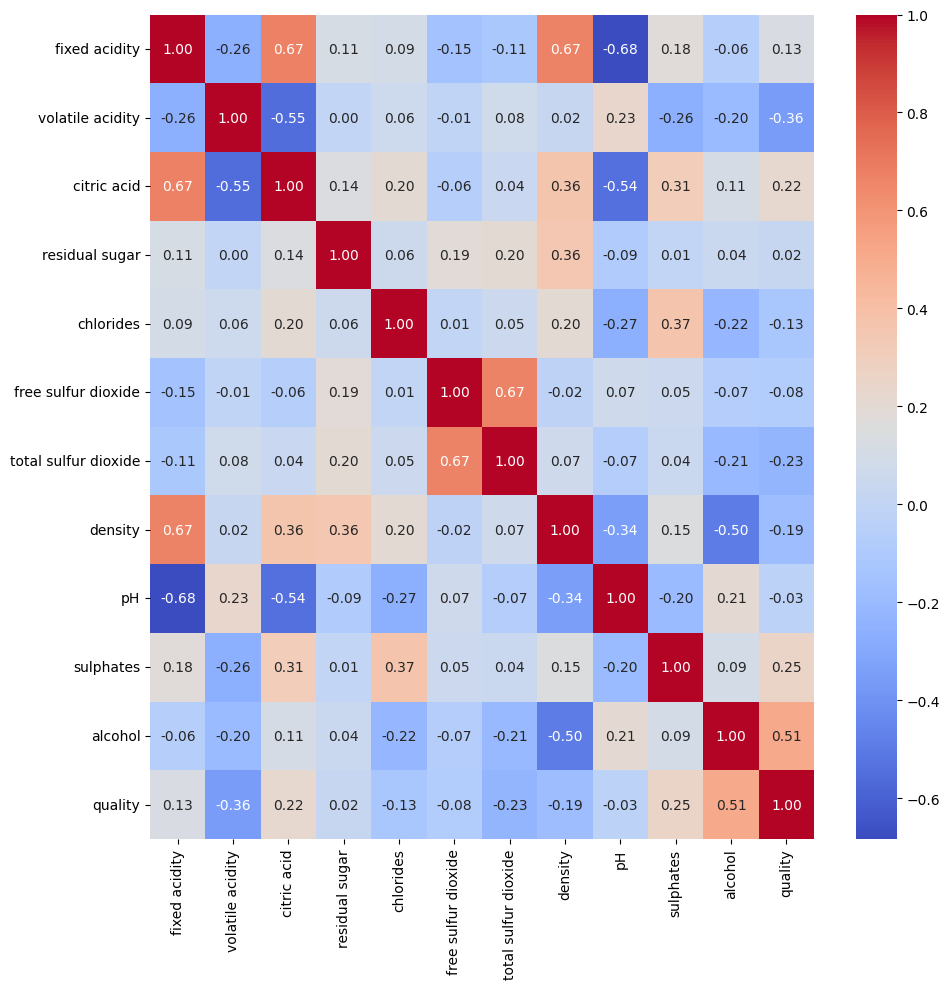

In [229]:
fig, axis = plt.subplots(figsize = (10, 10))

sns.heatmap(df.corr(), annot = True, fmt = ".2f", cmap = "coolwarm")

plt.tight_layout()

plt.show()

El mapa de correlaciones nos indica que no hay colinealidad entre ninguna variable.
No obstante, encontramos algunas correlaciones interesantes:
* fixed acidity y density (0.67): a mayor acidez, mayor densidad del vino.
* pH y fixed acidity (-0.68): cuanto más ácido, menor pH.

En cuanto a correlaciones con la variable objetivo encontramos:

* alcohol (0.51): Los vinos con más grado alcohólico suelen tener mejor puntuación.
* volatile acidity (-0.36): Cuanta más acidez volátil, peor calidad.

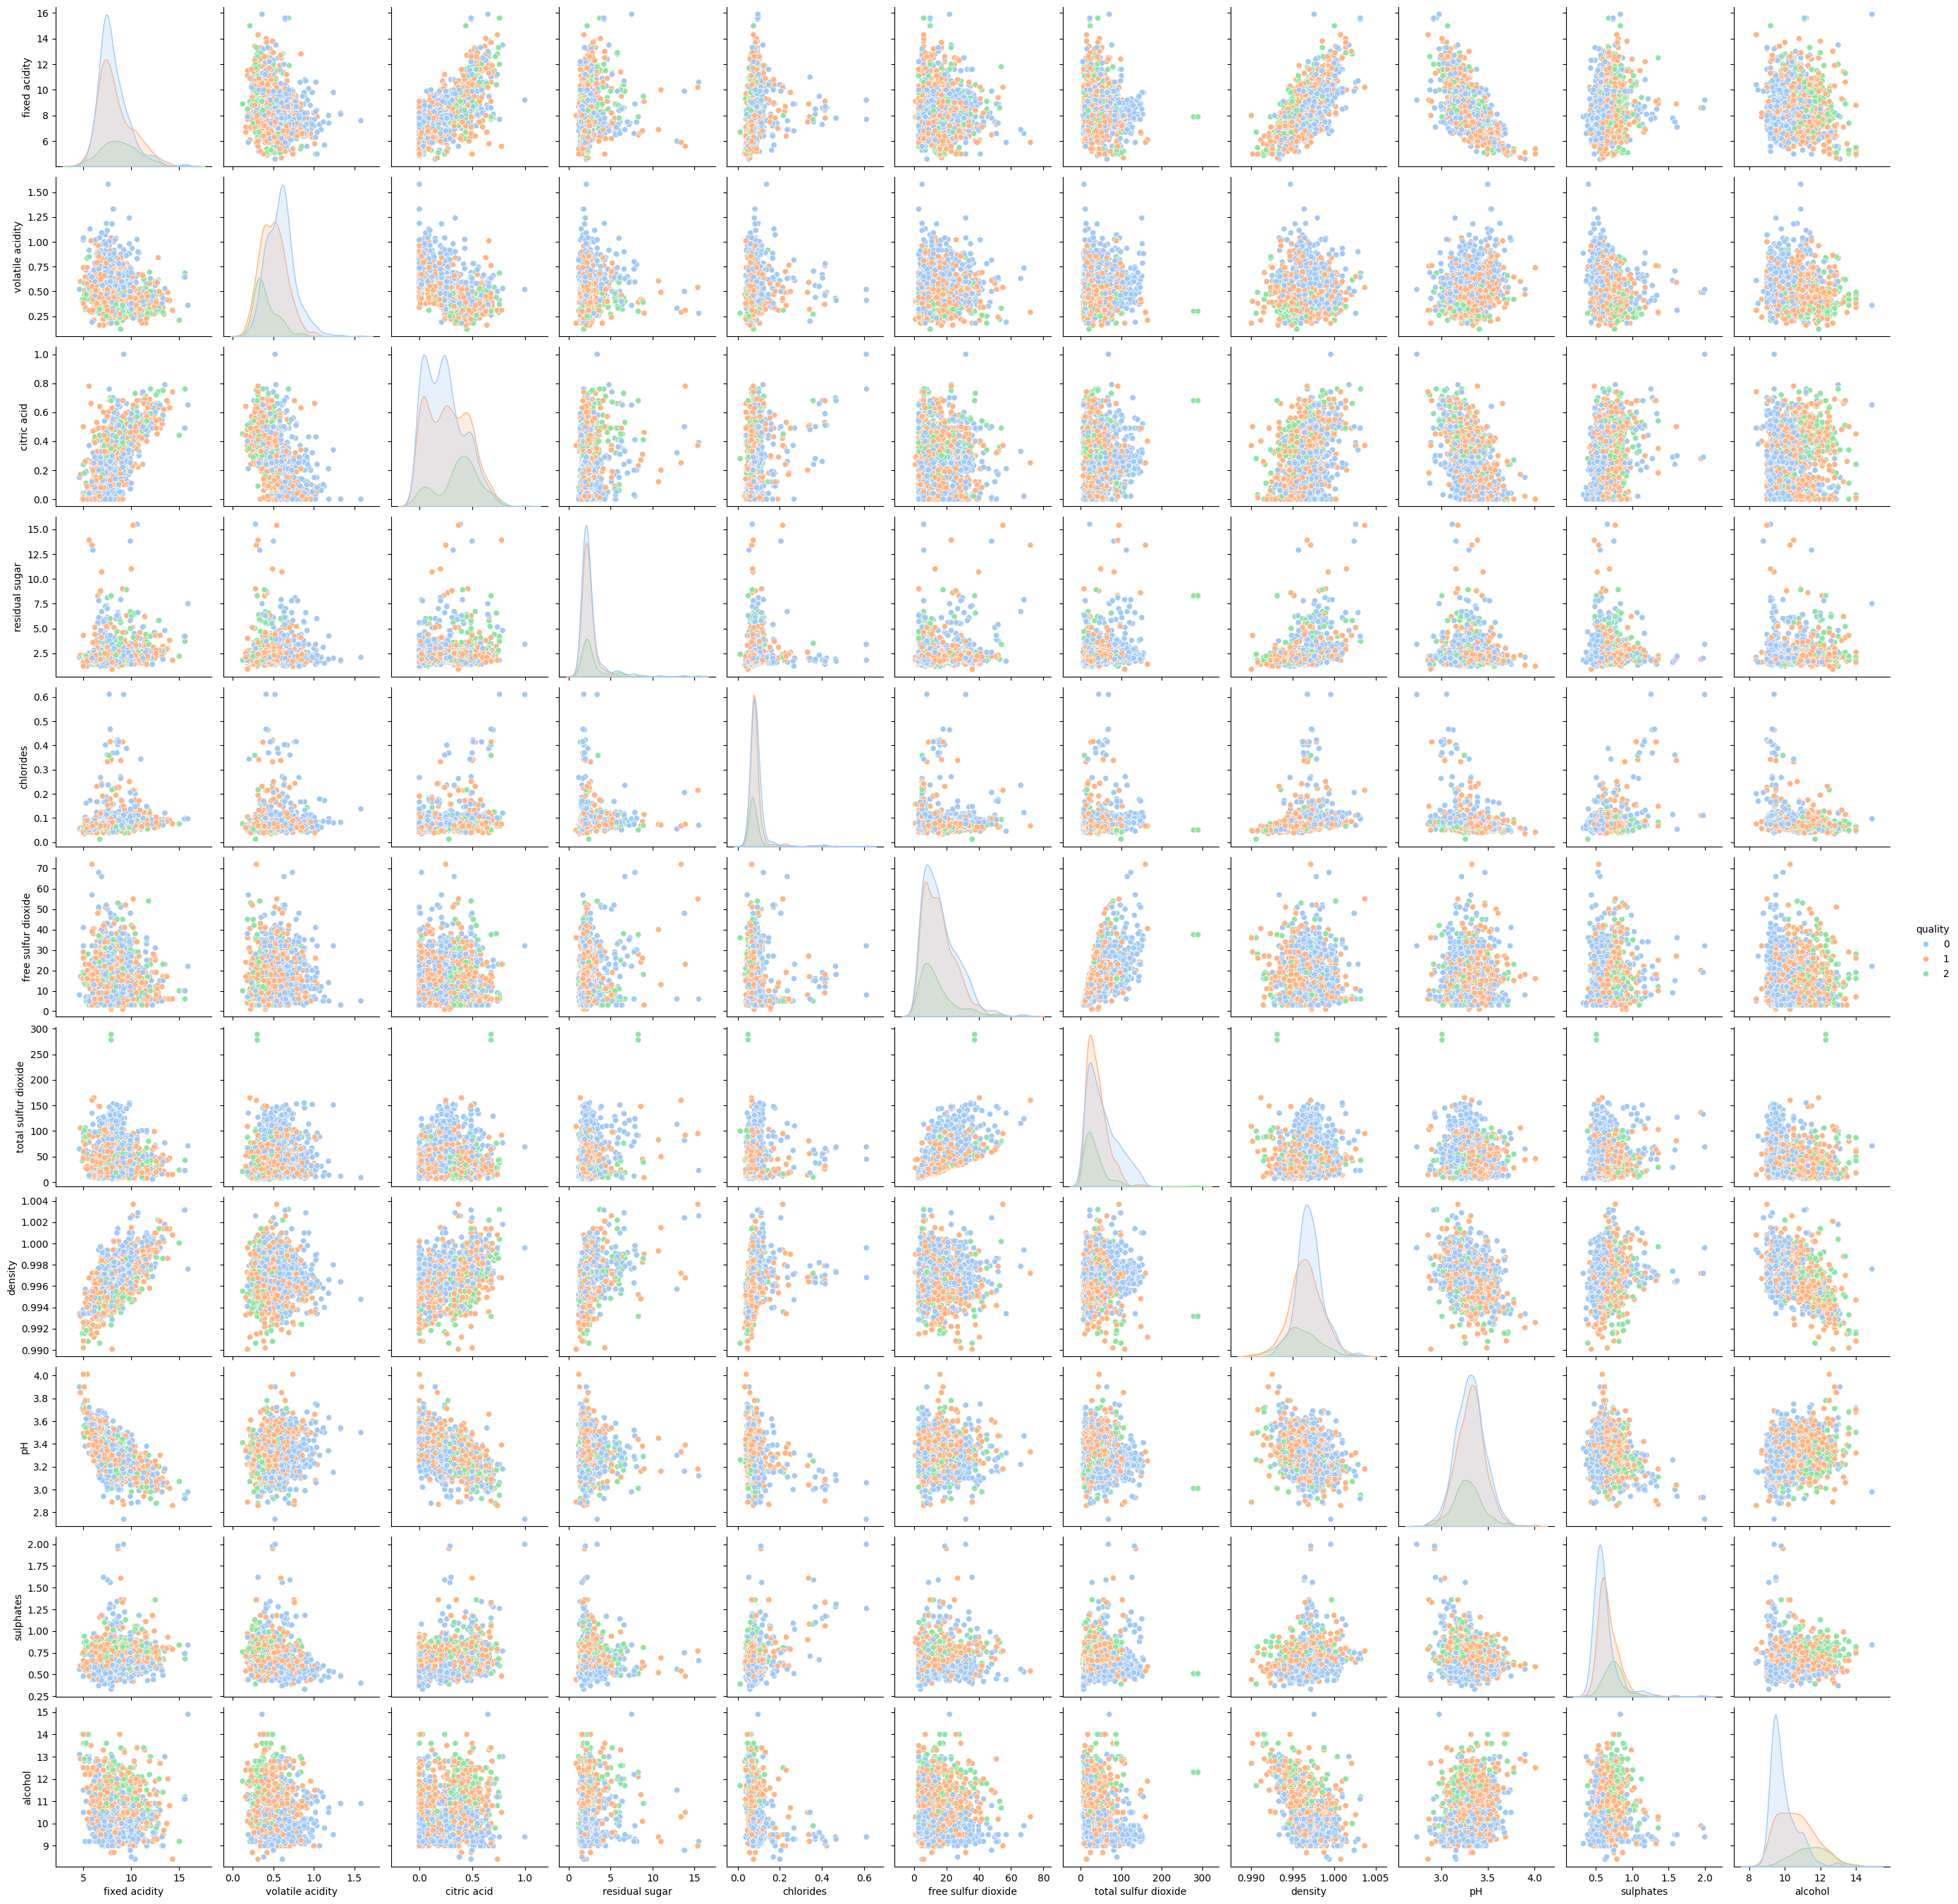

In [230]:
sns.pairplot(df, hue='quality', palette = 'pastel', vars=['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol'])
plt.show()

## Split

In [231]:
X = df.drop("quality", axis = 1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
493,8.7,0.690,0.31,3.0,0.086,23.0,81.0,1.00020,3.48,0.74,11.6
354,6.1,0.210,0.40,1.4,0.066,40.5,165.0,0.99120,3.25,0.59,11.9
342,10.9,0.390,0.47,1.8,0.118,6.0,14.0,0.99820,3.30,0.75,9.8
834,8.8,0.685,0.26,1.6,0.088,16.0,23.0,0.99694,3.32,0.47,9.4
705,8.4,1.035,0.15,6.0,0.073,11.0,54.0,0.99900,3.37,0.49,9.9


## Escalado

In [232]:
num_var = ['fixed acidity', 
           'volatile acidity', 
           'citric acid', 
           'residual sugar', 
           'chlorides', 
           'free sulfur dioxide', 
           'total sulfur dioxide', 
           'density', 
           'pH', 
           'sulphates', 
           'alcohol'
           ]
scaler = StandardScaler()

# entreno el escalador con los datos de entrenamiento
scaler.fit(X_train[num_var])

# aplico el escalador en ambos
X_train_final = scaler.transform(X_train[num_var])
X_train_final = pd.DataFrame(X_train_final, index = X_train.index, columns = num_var)

X_test_final = scaler.transform(X_test[num_var])
X_test_final = pd.DataFrame(X_test_final, index = X_test.index, columns = num_var)

X_train_final.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
493,0.218332,0.889712,0.192092,0.309726,-0.049642,0.691007,1.042934,1.846696,1.093500,0.458223,1.123177
354,-1.290166,-1.788783,0.652753,-0.805080,-0.455214,2.388473,3.593870,-3.004491,-0.400439,-0.401197,1.408272
342,1.494753,-0.784347,1.011045,-0.526378,0.599272,-0.957960,-0.991742,0.768655,-0.075669,0.515517,-0.587390
834,0.276351,0.861811,-0.063831,-0.665729,-0.009085,0.012020,-0.718427,0.089488,0.054238,-1.088733,-0.967516
705,0.044274,2.814880,-0.626861,2.399985,-0.313264,-0.472970,0.222990,1.199871,0.379008,-0.974144,-0.492358


In [233]:
# Guardamos los datos en formato .csv 
X_train_final.to_csv("../data/processed/X_train.csv", index=False)
X_test_final.to_csv("../data/processed/X_test.csv", index=False)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

## Modelo KNN

In [234]:
# modelo
model = KNeighborsClassifier()

# entrenamiento
model.fit(X_train_final, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [235]:
# predicion
y_pred_test = model.predict(X_test_final)
y_pred_train = model.predict(X_train_final)

y_pred_test

array([0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 2, 1, 1, 0, 0, 2, 0, 0, 2, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 2, 1, 0, 0, 0, 0, 1, 2, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 2, 1,
       1, 1, 2, 0, 1, 1, 1, 0, 1, 0, 2, 0, 1, 2, 0, 2, 0, 0, 1, 1, 0, 1,
       2, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       2, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 2, 0, 0, 0, 0, 0, 1, 1, 1, 2, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 2, 1, 2, 0, 1, 1, 1, 2, 1, 1, 1, 0, 2, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 2, 0, 1, 1, 1, 2, 1, 0, 1, 1,
       1, 1, 2, 1, 1, 0, 1, 2, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 2,
       1, 2, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 2, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 2, 0, 1, 0, 1, 0, 2, 1, 2, 1,

In [236]:
accuracy_test = accuracy_score(y_test, y_pred_test)
accuracy_train = accuracy_score(y_train, y_pred_train)

print("Accuracy Test: ", accuracy_test)
print("Accuracy Train: ", accuracy_train)

Accuracy Test:  0.584375
Accuracy Train:  0.746677091477717


Con los parámetros estándar del modelo solo obtenemos un accuracy test de 0.58. Probamos a cambiar los parámetros para mejorar este valor

In [237]:
# Probamos diferentes valores para k
k_range = range(1, 20)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors = k)

    knn.fit(X_train_final, y_train)
    scores.append(knn.score(X_test_final, y_test))

([<matplotlib.axis.XTick at 0x76401de0f8d0>,
 [Text(5, 0, '5'), Text(10, 0, '10'), Text(15, 0, '15'), Text(20, 0, '20')])

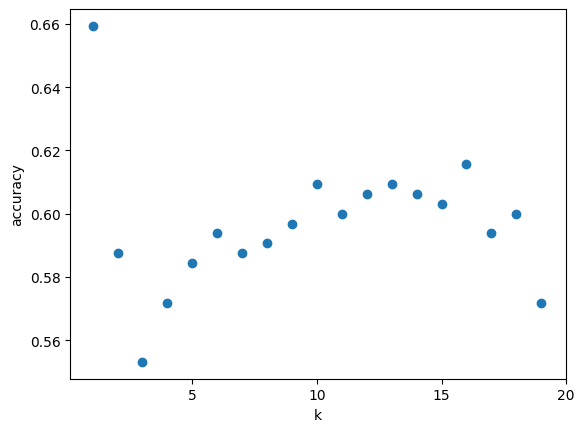

In [238]:
plt.figure()
plt.xlabel('k')
plt.ylabel('accuracy')

plt.scatter(k_range, scores)
plt.xticks([5,10,15,20])

Parece que el mejor valor de k con nuestros datos seria k = 10

In [239]:
# También probamos distintos valores de metric
distance_map = ['manhattan', 'cosine', 'euclidean', 'minkowski']
scores_2 = []

for d in distance_map:
    knn = KNeighborsClassifier(n_neighbors= 10,     # Incluimos ya el valor de k = 10 calculado en el paso anterior
                               metric = d)

    knn.fit(X_train_final, y_train)
    scores_2.append(knn.score(X_test_final, y_test))

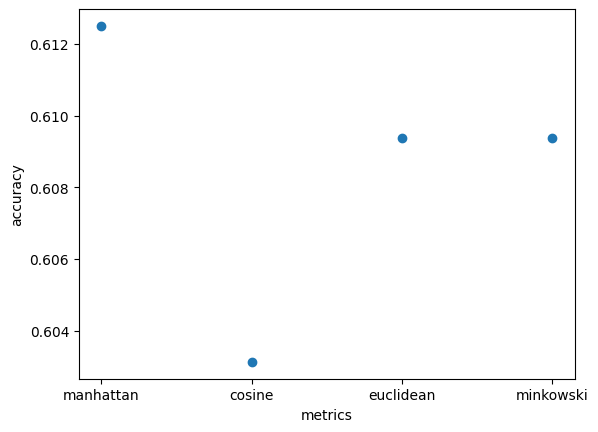

In [240]:
plt.figure()
plt.xlabel('metrics')
plt.ylabel('accuracy')

plt.scatter(distance_map, scores_2)


Obtenemos que para nuestros datos y un k = 10, el mejor parámetro de 'metric' sería 'manhattan'

In [241]:
# Como hay desbalance dentro de la variable quality, probamos dos posibilidades para 'weight'
weight_map = ['uniform', 'distance']
scores_3 = []

for w in weight_map:
    knn = KNeighborsClassifier(n_neighbors= 10, 
                               metric = 'manhattan', 
                               weights = w)

    knn.fit(X_train_final, y_train)
    scores_3.append(knn.score(X_test_final, y_test))

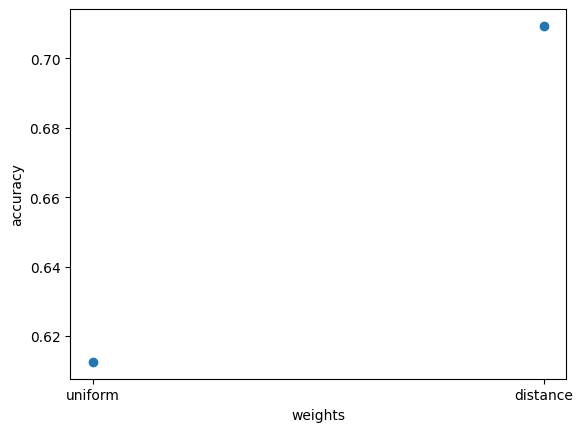

In [242]:
plt.figure()
plt.xlabel('weights')
plt.ylabel('accuracy')

plt.scatter(weight_map, scores_3)


En este caso, distance ofrece mejores resultados

In [243]:
# Creamos el modelo mejorado
model2 = KNeighborsClassifier(n_neighbors=10, metric='manhattan', weights='distance')

# entrenamiento
model2.fit(X_train_final, y_train)
# predicion
y_pred_test2 = model2.predict(X_test_final)
y_pred_train2 = model2.predict(X_train_final)

accuracy_test2 = accuracy_score(y_test, y_pred_test2)
accuracy_train2 = accuracy_score(y_train, y_pred_train2)

print("Accuracy Test: ", accuracy_test2)
print("Accuracy Train: ", accuracy_train2)

Accuracy Test:  0.709375
Accuracy Train:  1.0


In [249]:

print(classification_report(y_test, y_pred_test2))

              precision    recall  f1-score   support

           0       0.74      0.78      0.76       141
           1       0.66      0.63      0.64       132
           2       0.74      0.72      0.73        47

    accuracy                           0.71       320
   macro avg       0.71      0.71      0.71       320
weighted avg       0.71      0.71      0.71       320



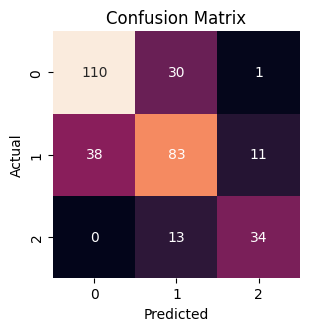

In [250]:
cm = confusion_matrix(y_test, y_pred_test2)
cm_df = pd.DataFrame(cm)

plt.figure(figsize = (3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)

plt.tight_layout()

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

El modelo tiene una precisión global del 71 %. Tiene el mejor rendimiento identificando los vinos de baja calidad (78 % predichos correctamente), seguido de la calidad alta (72 %) a pesar de que hay menos datos en esta categoría, mientras que presenta mayor dificultar al predecir un vino de clase media (63 %).



In [246]:
# Guardar el modelo
with open("../models/knn_classifier_k10_manhattan_distance.sav", "wb") as f:
    pickle.dump(model2, f)

# Introducimos nuevos datos

Creamos una función que reciba nuevos valores numéricos de las características de un nuevo vino y prediga la calidad de este

In [247]:
def predict_wine_quality(new_wine):
    columnas = ['fixed acidity', 
           'volatile acidity', 
           'citric acid', 
           'residual sugar', 
           'chlorides', 
           'free sulfur dioxide', 
           'total sulfur dioxide', 
           'density', 
           'pH', 
           'sulphates', 
           'alcohol'
    ]
    nw = pd.DataFrame([new_wine], columns = columnas)                       # Creamos un Daraset con el nuevo vino
    nw_esc = scaler.transform(nw)                                           # Escalamos los valores con el mismo escalador entrenado con X_train
    nw_esc = pd.DataFrame(nw_esc, index = nw.index, columns = nw.columns)   
    y_pred_nw = model.predict(nw_esc)                                       # Predecimos el valor de quality del nuevo vino
    if y_pred_nw == 0:
        print("Este vino probablemente sea de calidad baja 🍷")
    elif y_pred_nw == 1:
        print("Este vino probablemente sea de calidad media 🍷")
    else:
        print("Este vino probablemente sea de calidad alta 🍷")
        

predict_wine_quality([7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])

Este vino probablemente sea de calidad baja 🍷
